In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn - model selection & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Sklearn - metrics
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost
import xgboost as xgb

In [2]:
# Load your CSV file
df = pd.read_csv("aqi 2.3.csv")  # Replace with your actual CSV file

In [3]:
# Show first few rows
print("Data Sample:\n", df.head())

Data Sample:
    dhtTemp  dhthum  LDR value  rainValue    pressure  altitude  aqi value
0     30.2    79.0        687        999  1008.62531  28.16959        396
1     29.8    77.0        688        404  1008.61737  28.23564        397
2     29.9    78.0        715        506  1008.62201  28.19682        413
3     30.8    80.0        708        585  1008.61108  28.28807        345
4     31.3    81.0        753        584  1008.59741  28.40253        366


In [4]:
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 dhtTemp      0
dhthum       0
LDR value    0
rainValue    0
pressure     0
altitude     0
aqi value    0
dtype: int64


In [5]:
# Drop rows with missing values (or use fillna if you prefer)
df.dropna(inplace=True)

In [6]:
# Define features and target
X = df[['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']]
y = df['aqi value']

In [7]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Predict on test data
y_pred = model.predict(X_test)

In [10]:
# Evaluate model
print("\nModel Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Model Coefficients: [-0.89898361 -4.86666218  0.17247998 -0.05191577 -7.95275106  0.3249091 ]
Intercept: 8589.066718034092
Mean Squared Error: 10601.686967755428
R² Score: 0.3562231898530407


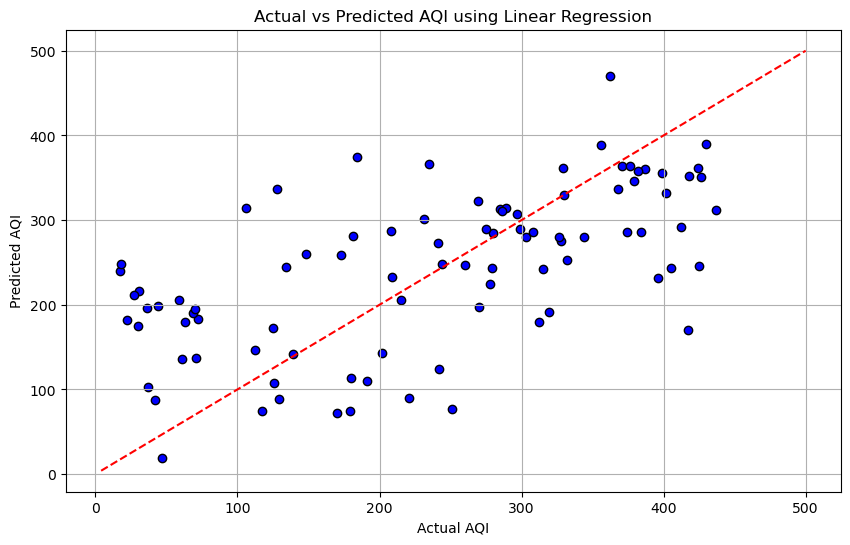

In [11]:
# Plot actual vs predicted AQI
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI using Linear Regression")
plt.grid(True)
plt.show()

In [12]:
# Load your CSV file
df = pd.read_csv("aqi 2.3.csv")  # Replace with your actual file name

In [13]:
# Check and drop missing values
df.dropna(inplace=True)

In [14]:
# Define features and target variable
X = df[['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']]
y = df['aqi value']

In [15]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Initialize and train the Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
# Predict AQI values
y_pred = model.predict(X_test)

In [18]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 6605.758241758242
R² Score: 0.5988719547733007


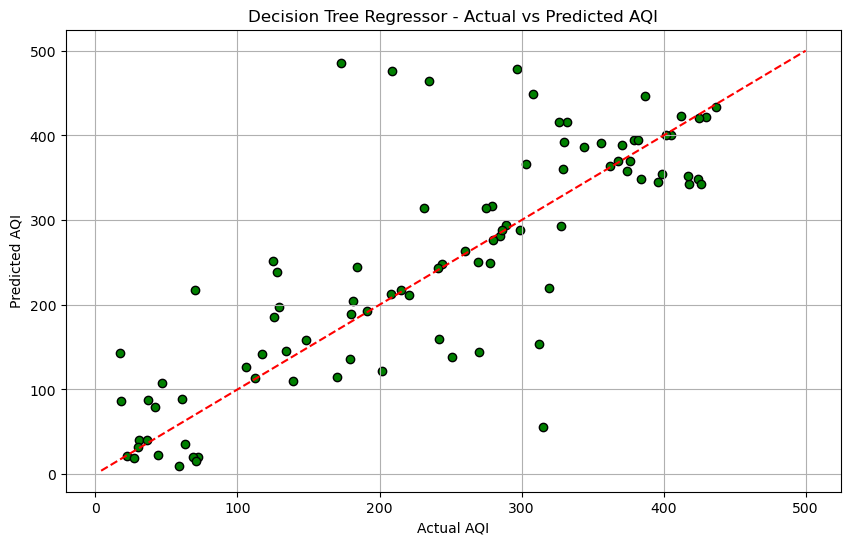

In [20]:
# Plot actual vs predicted AQI
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='green', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Decision Tree Regressor - Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [21]:
# Load CSV data
df = pd.read_csv("aqi 2.3.csv")  # Replace with your actual CSV filename

# Drop missing values
df.dropna(inplace=True)

# Define features and target
features = ['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']
X = df[features]
y = df['aqi value']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 2946.8316252747254
R² Score: 0.8210566045262895


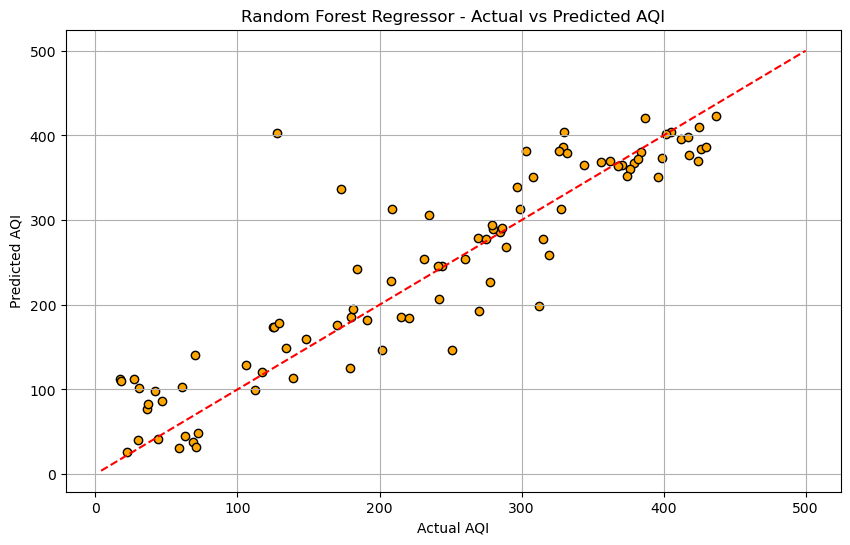

In [23]:
# Plot actual vs predicted AQI
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='orange', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest Regressor - Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [24]:
# Optional: Feature Importance
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)

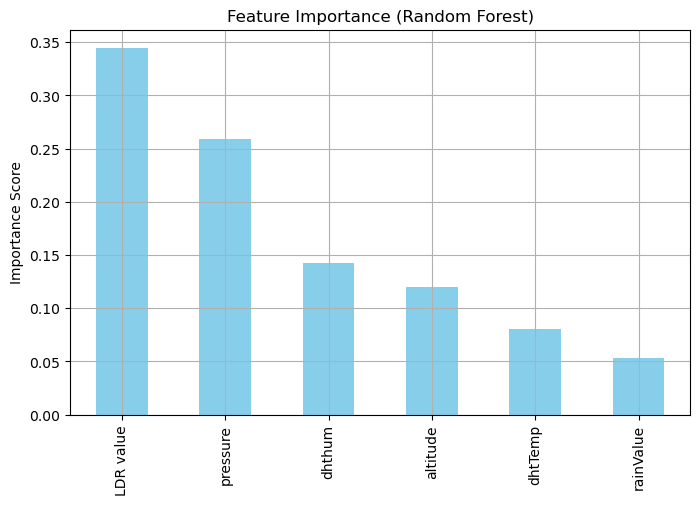

In [25]:
# Plot feature importance
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='skyblue')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.grid(True)
plt.show()

In [26]:
# Load the dataset
df = pd.read_csv("aqi 2.3.csv")  # Replace with your actual CSV file

# Drop rows with missing values
df.dropna(inplace=True)

# Define input features and target variable
features = ['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']
X = df[features]
y = df['aqi value']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the XGBoost Regressor
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [27]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 3174.606689453125
R² Score: 0.807225227355957


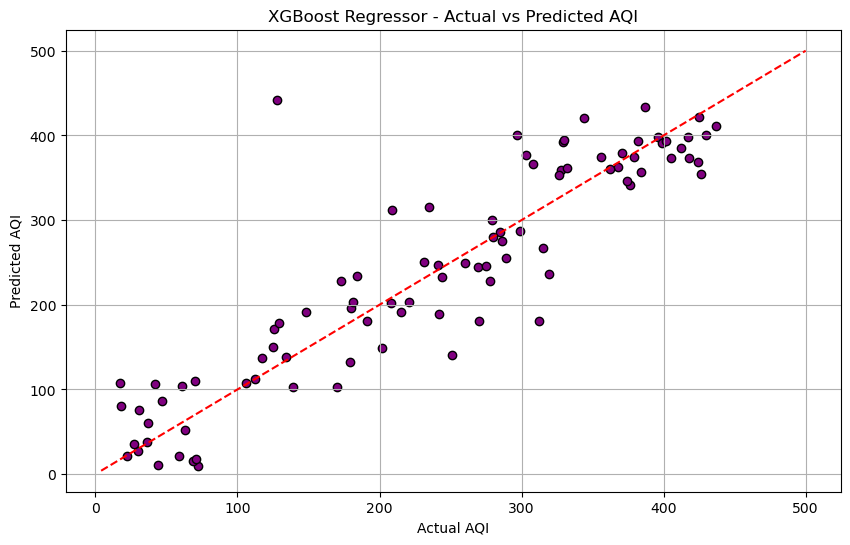

In [28]:
# Plot actual vs predicted AQI
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='purple', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("XGBoost Regressor - Actual vs Predicted AQI")
plt.grid(True)
plt.show()

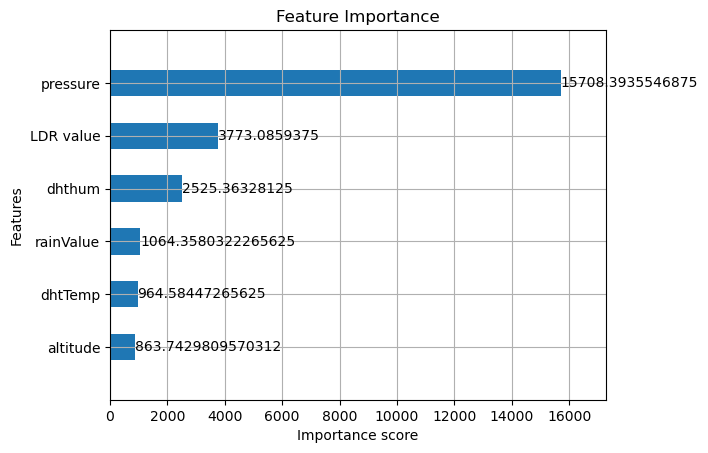

In [29]:
# Feature Importance Plot
xgb.plot_importance(model, height=0.5, importance_type='gain', title='Feature Importance')
plt.show()

In [30]:
# Load the CSV file
df = pd.read_csv("aqi 2.3.csv")  # Replace with your actual file name

# Drop missing values
df.dropna(inplace=True)

# Define input features and target
features = ['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']
X = df[features]
y = df['aqi value']

# Standardize the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train SVR model
model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
model.fit(X_train, y_train)

# Predict and inverse scale
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Evaluate the model
mse = mean_squared_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

In [31]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 4121.474013654352
R² Score: 0.7497276233788159


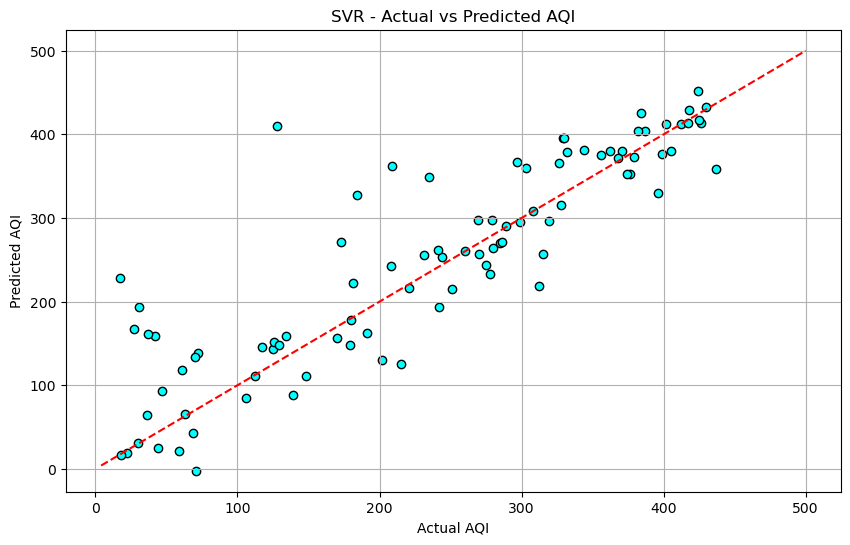

In [32]:
# Plot actual vs predicted AQI
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred, color='cyan', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("SVR - Actual vs Predicted AQI")
plt.grid(True)
plt.show()

Results saved to model_comparison_results.csv
               Model           MSE  R2 Score
0  Linear Regression  10601.686968  0.356223
1      Decision Tree   6605.758242  0.598872
2      Random Forest   2946.831625  0.821057
3            XGBoost   3174.606689  0.807225
4                SVR   4121.474014  0.749728


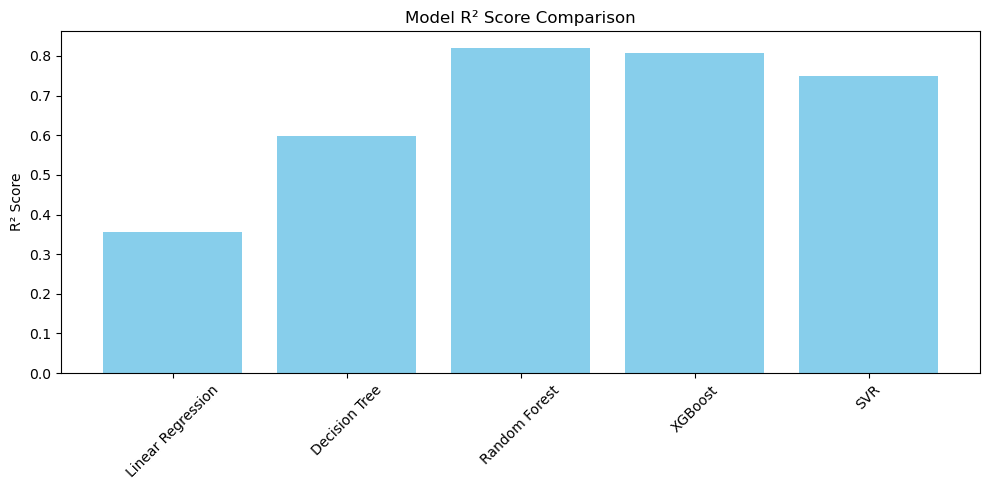

In [33]:
# Load dataset
df = pd.read_csv("aqi 2.3.csv")  # <-- Replace with your file if needed
df.dropna(inplace=True)

# Features and Target
features = ['dhtTemp', 'dhthum', 'LDR value', 'rainValue', 'pressure', 'altitude']
target = 'aqi value'
X = df[features]
y = df[target]

# Standard scaling for SVR
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=100, epsilon=0.1)
}

results = []

for name, model in models.items():
    if name == "SVR":
        model.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        y_true = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_true = y_test

    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results.append({"Model": name, "MSE": mse, "R2 Score": r2})

# Save to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results.csv", index=False)
print("Results saved to model_comparison_results.csv")
print(results_df)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['R2 Score'], color='skyblue')
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()